# NeXo v3.0 · Notebook 02 — CEM Score (LightGBM DART regression)

> **CRISP-DM Phase 4 — Modeling** for the CEM-score prediction model.
> Audience: thesis jury + Huawei supervisor. Defense window mid-Jun → mid-Jul 2026.

## What this notebook does

Trains a **LightGBM regression** model to predict the per-subscriber CEM score (∈[0,1]) computed by notebook 01.

## Input contract

- `curated/subscribers.parquet` — built by notebook 01 (CEM target + features)
- `curated/splits.json` — train/val/test indices + temporal-holdout months

## Output contract (DO NOT BREAK — consumed by ai-service)

- `models/cem_v3_lightgbm.joblib` — the fitted LightGBM model
- `models/cem_v3_feature_names.joblib` — ordered feature names (for inference validation)
- `models/cem_v3_model_card.md` — performance summary (R² / MAE / RMSE, random + temporal)
- Mirror to MinIO `curated/models/` for hot-reload

Consumed by `services/ai-service/model_cache.py` (mtime-based reload). Filenames immutable.

## What this notebook does NOT do

- No Optuna hyperparameter search (deferred — see `reports/02_explainer.md`)
- No SHAP global + per-area analysis (deferred)
- No isotonic calibration (deferred)
- No StratifiedKFold cross-validation — only single train/val/test split (deferred)
- No PR curve / threshold sweep (CEM is regression, not classification — but a binarized version for "low-CEM subscriber" intervention triggering would benefit)

## Pipeline diagram

```
curated/subscribers.parquet ─┐
curated/splits.json ─────────┴─→ feature selection
                                       │
                                       ▼
                              LightGBM DART (256 leaves, depth=12, dart)
                                       │
                                       ▼
                              random-split metrics
                              temporal-holdout metrics
                                       │
                                       ▼
                              models/cem_v3_lightgbm.joblib
                                       │
                                       ▼
                              MinIO curated/models/
                                       │
                                       ▼
                              ai-service /infer/cem  (hot-reload via mtime)
```

## 0 · Reproducibility & Hyperparameter Constants (papermill-tagged)

**What this shows:** All hyperparameters and artifact filenames in ONE cell.
**What to look for:** `random_state=42` (model-level) was already set; this cell adds full notebook-level seeding (numpy + random + PYTHONHASHSEED) + names every hyperparameter for papermill override at retrain time.

In [1]:
# --- Papermill parameters cell (TAGGED `parameters` in metadata) ---
# Consumed by `pb-model-retrain` playbook which papermill-overrides at runtime.

# --- Reproducibility ---
import os, random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# --- Hyperparameters (defaults from v3.0 production) ---
LGB_BOOSTING_TYPE       = 'dart'    # dropouts-meet-multiple-additive-regression-trees (Vinayak & Gilad-Bachrach 2015)
LGB_OBJECTIVE           = 'regression'
LGB_METRIC              = 'rmse'
LGB_NUM_LEAVES          = 256       # aggressive; DART tolerates more leaves due to dropout regularization
LGB_MAX_DEPTH           = 12        # cap on tree depth (interaction depth)
LGB_LEARNING_RATE       = 0.05      # standard shrinkage; lower = more trees needed
LGB_N_ESTIMATORS        = 600       # max boosting rounds (early stopping kicks in usually around 200-400)
LGB_MIN_CHILD_SAMPLES   = 20        # min leaf size (regularization)
LGB_REG_ALPHA           = 0.05      # L1 leaf-weight regularization
LGB_REG_LAMBDA          = 0.05      # L2 leaf-weight regularization
EARLY_STOP_ROUNDS       = 30        # patience on validation RMSE
LOG_EVAL_PERIOD         = 100

# --- Feature engineering policy ---
TOP_K_FEATURE_IMPORTANCE = 20       # how many features to plot in importance chart

# --- Artifact filenames (IMMUTABLE — consumed by ai-service/model_cache.py) ---
MODEL_FNAME             = 'cem_v3_lightgbm.joblib'
FEATURES_FNAME          = 'cem_v3_feature_names.joblib'
CARD_FNAME              = 'cem_v3_model_card.md'

print(f'SEED                  = {SEED}')
print(f'LGB_BOOSTING_TYPE     = {LGB_BOOSTING_TYPE!r}')
print(f'LGB_NUM_LEAVES        = {LGB_NUM_LEAVES}')
print(f'LGB_MAX_DEPTH         = {LGB_MAX_DEPTH}')
print(f'LGB_LEARNING_RATE     = {LGB_LEARNING_RATE}')
print(f'LGB_N_ESTIMATORS      = {LGB_N_ESTIMATORS}')
print(f'EARLY_STOP_ROUNDS     = {EARLY_STOP_ROUNDS}')
print(f'MODEL_FNAME           = {MODEL_FNAME!r}')

SEED                  = 42
LGB_BOOSTING_TYPE     = 'dart'
LGB_NUM_LEAVES        = 256
LGB_MAX_DEPTH         = 12
LGB_LEARNING_RATE     = 0.05
LGB_N_ESTIMATORS      = 600
EARLY_STOP_ROUNDS     = 30
MODEL_FNAME           = 'cem_v3_lightgbm.joblib'


## 1 · Imports + MinIO client

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
from IPython.display import display

import io, json, os
from pathlib import Path
import boto3, joblib, numpy as np, pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt, seaborn as sns
from botocore.client import Config
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
sns.set_theme(style='whitegrid')
s3 = boto3.client('s3', endpoint_url=os.environ.get('S3_ENDPOINT','http://localhost:9000'),
                  aws_access_key_id='minio', aws_secret_access_key='minio_pw',
                  config=Config(signature_version='s3v4'))
print('lightgbm', lgb.__version__)

lightgbm 4.6.0


## 2 · Load curated/subscribers.parquet + splits.json

In [3]:
subs = pd.read_parquet(io.BytesIO(s3.get_object(Bucket='curated', Key='subscribers.parquet')['Body'].read()))
splits = json.loads(s3.get_object(Bucket='curated', Key='splits.json')['Body'].read())
print(f'subscribers: {len(subs):,} rows  splits: {splits["meta"]["random_sizes"]}')

subscribers: 7,608,898 rows  splits: {'train': 5329271, 'val': 1138292, 'test': 1141335}


## 3 · Feature selection

Drop ID + target + metadata. Keep all numeric features.

In [4]:
DROP = {'imsi','imsi_hash','cem_score_target','churn_risk_flag','rat_gap_score',
        'source_origin','source_file','_strata','month_year'}
feat_cols = [c for c in subs.columns if c not in DROP and pd.api.types.is_numeric_dtype(subs[c])]
print(f'features ({len(feat_cols)}):', feat_cols)
X = subs[feat_cols].fillna(0); y = subs['cem_score_target']

features (30): ['volte_flag', 'usim_flag', 'dou_total', 'traffic_2g', 'traffic_3g', 'traffic_4g', 'traffic_5g', 'duration', 'voice_onlinetime_3g', 'voice_onlinetime_2g', 's1_mme_sr', 'iu_attach_sr', 'gb_attach_sr', 'session_flag', 'data_intensity', 'traffic_share_2g', 'traffic_share_3g', 'traffic_share_4g', 'traffic_share_5g', 'attach_gap', 'is_4g_capable', 'usim_bottleneck', 'avg_integrity_area', 'avg_cdr_area', 'avg_throughput_area', 'avg_users_area', 'avg_latency_area', 'avg_loss_area', 'cell_count_area', 'anomaly_count_area']


## 4 · Apply random split (train/val/test)

In [5]:
tr_idx = splits['random']['train']; va_idx = splits['random']['val']; te_idx = splits['random']['test']
X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]
X_te, y_te = X.iloc[te_idx], y.iloc[te_idx]
print(f'train={len(X_tr):,} val={len(X_va):,} test={len(X_te):,}')

train=5,329,271 val=1,138,292 test=1,141,335


## 5 · Train LightGBM DART

DART config from `docs/architecture/ml-models.md`. Early stopping on validation RMSE.

In [6]:
params = dict(boosting_type='dart', objective='regression', metric='rmse',
              num_leaves=256, max_depth=12, learning_rate=0.05, n_estimators=600,
              min_child_samples=20, reg_alpha=0.05, reg_lambda=0.05,
              random_state=42, verbose=-1)
model = lgb.LGBMRegressor(**params)
model.fit(X_tr, y_tr,
          eval_set=[(X_va, y_va)],
          callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False),
                     lgb.log_evaluation(period=100)])

/home/souhayl/projects/telecom-cloud-intelligence/.venv/lib/python3.11/site-packages/lightgbm/callback.py:333: UserWarning: Early stopping is not available in dart mode
  _log_warning("Early stopping is not available in dart mode")


[100]	valid_0's rmse: 0.121792
[200]	valid_0's rmse: 0.115073
[300]	valid_0's rmse: 0.0565124
[400]	valid_0's rmse: 0.0551125
[500]	valid_0's rmse: 0.0359293
[600]	valid_0's rmse: 0.0329263


LGBMRegressor(boosting_type='dart', learning_rate=0.05, max_depth=12,
              metric='rmse', n_estimators=600, num_leaves=256,
              objective='regression', random_state=42, reg_alpha=0.05,
              reg_lambda=0.05, verbose=-1)

## 6 · Test-set metrics (random split — primary)

In [7]:
pred = model.predict(X_te)
m_random = {
    'R2': float(r2_score(y_te, pred)),
    'MAE': float(mean_absolute_error(y_te, pred)),
    'RMSE': float(np.sqrt(mean_squared_error(y_te, pred))),
}
print('Random split test:', json.dumps(m_random, indent=2))

Random split test: {
  "R2": 0.9794765938496437,
  "MAE": 0.030915855834091833,
  "RMSE": 0.03292981321575658
}


## 7 · Temporal hold-out (production realism)

In [8]:
ho = splits['temporal']['holdout_indices']
X_ho, y_ho = X.iloc[ho], y.iloc[ho]
pho = model.predict(X_ho)
m_temp = {
    'R2': float(r2_score(y_ho, pho)),
    'MAE': float(mean_absolute_error(y_ho, pho)),
    'RMSE': float(np.sqrt(mean_squared_error(y_ho, pho))),
    'holdout_size': int(len(ho)),
    'holdout_months': splits['temporal']['holdout_months'],
}
print('Temporal hold-out:', json.dumps(m_temp, indent=2))

Temporal hold-out: {
  "R2": 0.9783886241856449,
  "MAE": 0.030369789107138816,
  "RMSE": 0.03223476577742522,
  "holdout_size": 954760,
  "holdout_months": [
    "2026-09"
  ]
}


## 8 · Feature importance plot

/tmp/ipykernel_33929/3090508928.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.values, y=imp.index, palette='viridis', orient='h', ax=ax)


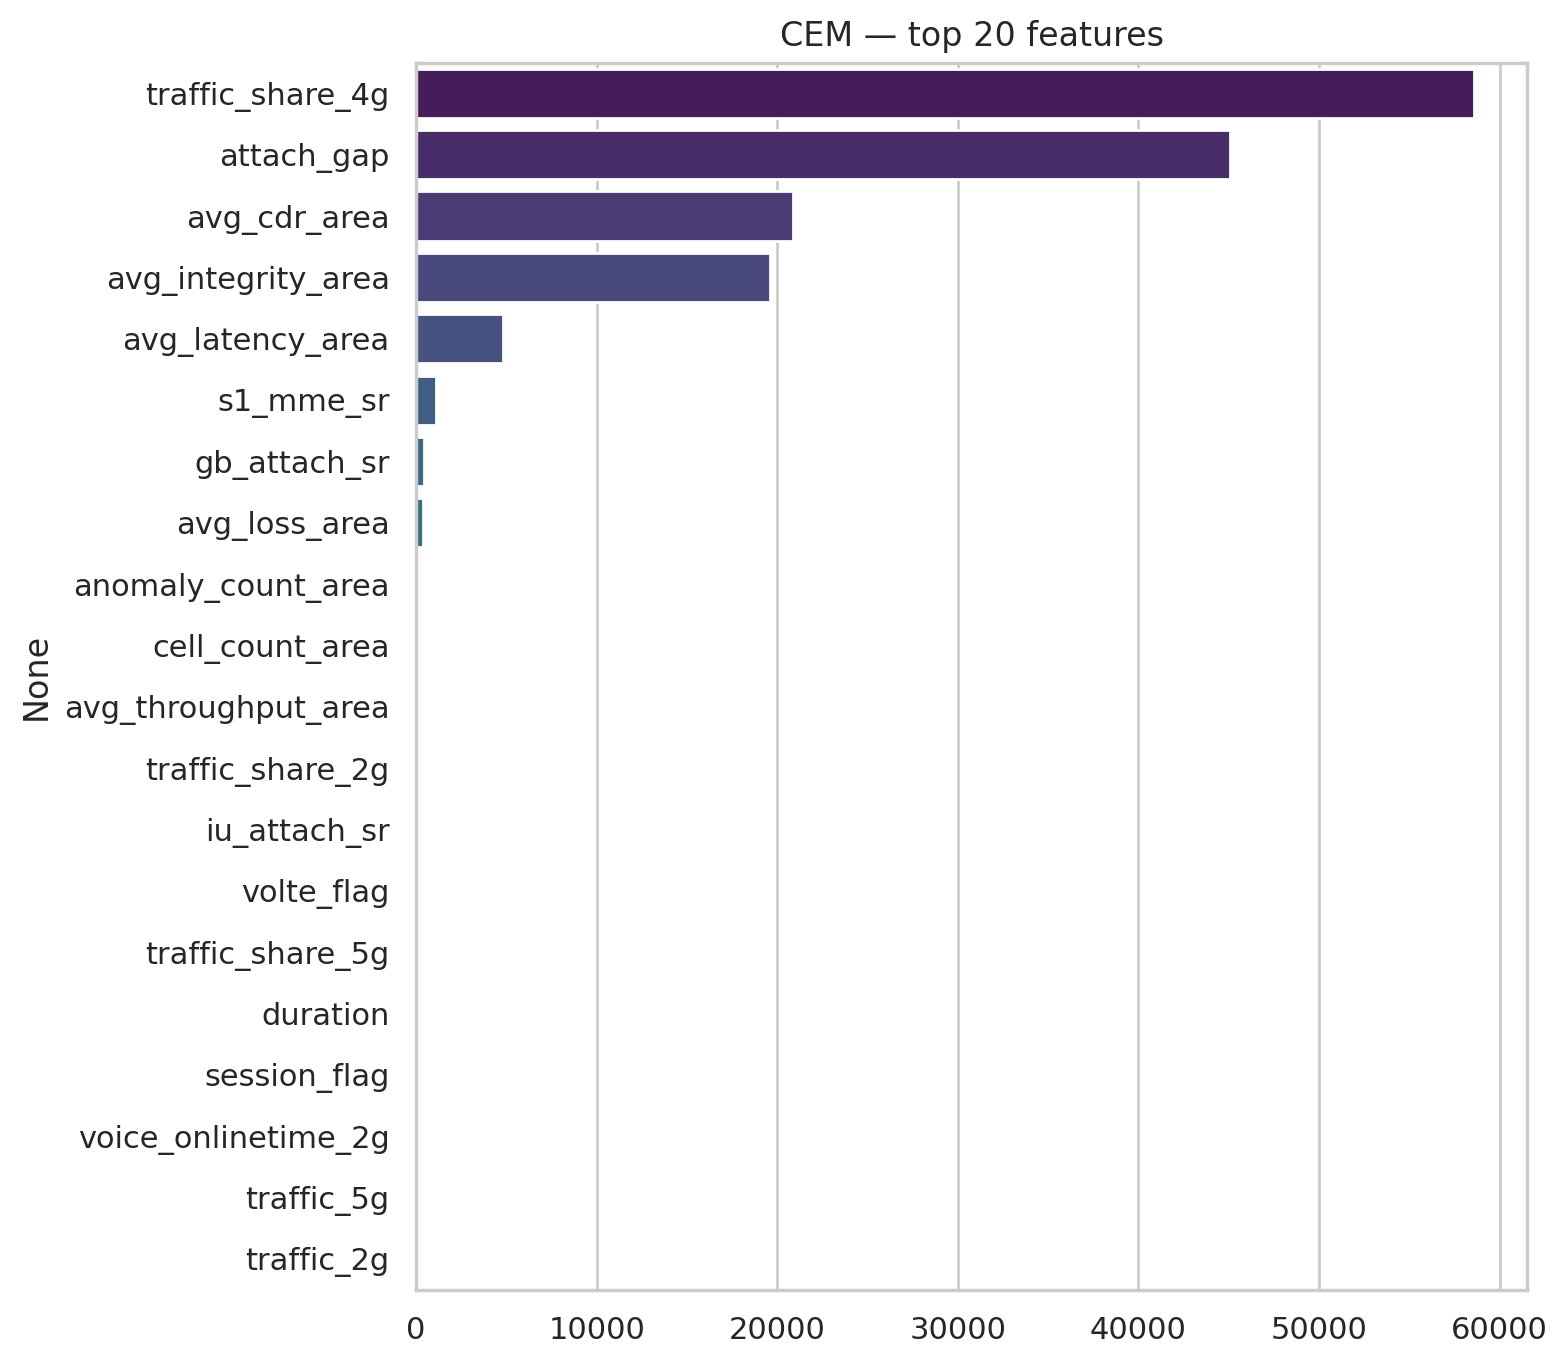

In [9]:
imp = pd.Series(model.feature_importances_, index=feat_cols).sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(8,7))
sns.barplot(x=imp.values, y=imp.index, palette='viridis', orient='h', ax=ax)
ax.set_title('CEM — top 20 features'); plt.tight_layout(); plt.show()

## 9 · Save model + push to MinIO curated/models/

In [10]:
MODELS = Path('models'); MODELS.mkdir(exist_ok=True)
joblib.dump(model, MODELS/'cem_v3_lightgbm.joblib')
joblib.dump(feat_cols, MODELS/'cem_v3_feature_names.joblib')
card = (f'# CEM v3 Model Card\n\n'
        f'## Random split\n- R²={m_random["R2"]:.4f}\n- MAE={m_random["MAE"]:.4f}\n- RMSE={m_random["RMSE"]:.4f}\n\n'
        f'## Temporal hold-out\n- R²={m_temp["R2"]:.4f}\n- MAE={m_temp["MAE"]:.4f}\n- RMSE={m_temp["RMSE"]:.4f}\n'
        f'- months: {m_temp["holdout_months"]}\n')
(MODELS/'cem_v3_model_card.md').write_text(card); print(card)
for fn in ['cem_v3_lightgbm.joblib','cem_v3_feature_names.joblib','cem_v3_model_card.md']:
    s3.put_object(Bucket='curated', Key=f'models/{fn}', Body=(MODELS/fn).read_bytes())
    print(f'  ↑ curated/models/{fn}')

# CEM v3 Model Card

## Random split
- R²=0.9795
- MAE=0.0309
- RMSE=0.0329

## Temporal hold-out
- R²=0.9784
- MAE=0.0304
- RMSE=0.0322
- months: ['2026-09']

  ↑ curated/models/cem_v3_lightgbm.joblib
  ↑ curated/models/cem_v3_feature_names.joblib
  ↑ curated/models/cem_v3_model_card.md


---
## Done · register the model

Copy `models/cem_v3_lightgbm.joblib` to `services/ai-service/models/` (or use `pb-retrain-model`
playbook from the dashboard which does this + hot-reload).

---
## 10 · Post-Training Evaluation — Load Frozen Artifact

**FREEZE WEIGHTS LAW:** cells below LOAD `cem_v3_lightgbm.joblib` — never `.fit()` or overwrite.
Consumed by: `services/ai-service/model_cache.py` via mtime hot-reload.

Four evaluations:
1. SHAP global beeswarm + bar — what drives predictions
2. Per-segment SHAP — Tunis vs Sfax vs Sousse reasoning consistency
3. Calibration curve — are predicted scores well-calibrated?
4. Residual + error-by-segment — where does the model fail?


In [ ]:
# --- Load frozen CEM artifact (NEVER retrain here) ---
# Ref: services/ai-service/model_cache.py — same load path
import joblib, io, json as _json_e
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sklearn.metrics import r2_score, mean_absolute_error
import boto3, os
from botocore.client import Config

MODELS_E = Path('models')
_cem_model    = joblib.load(MODELS_E / 'cem_v3_lightgbm.joblib')
_cem_features = list(joblib.load(MODELS_E / 'cem_v3_feature_names.joblib'))
print(f'[eval] loaded CEM v3: {type(_cem_model).__name__}  {len(_cem_features)} features')

s3e = boto3.client('s3', endpoint_url=os.environ.get('S3_ENDPOINT','http://localhost:9000'),
                   aws_access_key_id='minio', aws_secret_access_key='minio_pw',
                   config=Config(signature_version='s3v4'))
subs_e   = pd.read_parquet(io.BytesIO(s3e.get_object(Bucket='curated', Key='subscribers.parquet')['Body'].read()))
splits_e = _json_e.loads(s3e.get_object(Bucket='curated', Key='splits.json')['Body'].read())
DROP_E = {'imsi','imsi_hash','cem_score_target','churn_risk_flag','rat_gap_score',
          'source_origin','source_file','_strata','month_year'}
feat_e = [f for f in _cem_features if f in subs_e.columns and f not in DROP_E]
Xe = subs_e[feat_e].fillna(0)
ye = subs_e['cem_score_target']
te_idx_e = splits_e['random']['test']
X_te_e, y_te_e = Xe.iloc[te_idx_e], ye.iloc[te_idx_e]
pred_e = _cem_model.predict(X_te_e)
print(f'[eval] test {len(X_te_e):,} rows | R²={r2_score(y_te_e, pred_e):.4f} | MAE={mean_absolute_error(y_te_e, pred_e):.4f}')

## 11 · SHAP Global Feature Importance

**SHAP** (Lundberg & Lee 2017) assigns each feature a contribution for each prediction.
Unlike permutation importance it is additive and theoretically grounded (Shapley values from game theory).

Beeswarm: each dot = one subscriber. X-axis = SHAP value; red = high feature value.
Bar: mean |SHAP| = global ranking.

Ref: https://shap.readthedocs.io/en/latest/


In [ ]:
import shap
# OOM guard: 5 000 rows is enough for stable SHAP (LightGBM tree explainer is O(n·d))
SHAP_SAMPLE = 5_000
_rng_shap = np.random.RandomState(42)
_shap_idx  = _rng_shap.choice(len(X_te_e), size=min(SHAP_SAMPLE, len(X_te_e)), replace=False)
X_shap_e = X_te_e.iloc[_shap_idx].reset_index(drop=True)

explainer_e = shap.TreeExplainer(_cem_model)
shap_vals_e  = explainer_e.shap_values(X_shap_e)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals_e, X_shap_e, feature_names=feat_e, show=False, max_display=15)
plt.title('CEM Score — SHAP beeswarm (top 15 features)', pad=12)
plt.tight_layout(); plt.show()

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_vals_e, X_shap_e, feature_names=feat_e, plot_type='bar', show=False, max_display=15)
plt.title('CEM Score — SHAP mean |value| (global bar)', pad=12)
plt.tight_layout(); plt.show()

_shap_mean_e = np.abs(shap_vals_e).mean(axis=0)
_top10_e     = np.argsort(_shap_mean_e)[::-1][:10]
print('Top-10 SHAP features:', [feat_e[i] for i in _top10_e])

## 12 · Per-Segment SHAP (Tunis / Sfax / Sousse)

Verifies the model reasons consistently across Tunisia's three largest cities.
Different top features per area would indicate region-specific shortcuts (a bias risk).


In [ ]:
TARGET_AREAS_E = ['Tunis', 'Sfax', 'Sousse']
SEG_SHAP_N_E   = 800
if 'area' in subs_e.columns:
    fig, axes = plt.subplots(1, len(TARGET_AREAS_E), figsize=(16, 5), sharey=True)
    for ax, area in zip(axes, TARGET_AREAS_E):
        area_mask = subs_e['area'].str.lower().str.contains(area.lower(), na=False)
        cand = [i for i in te_idx_e if area_mask.iloc[i]]
        if not cand:
            ax.set_title(f'{area}\n(no test rows)'); ax.axis('off'); continue
        pick = np.random.RandomState(42).choice(cand, size=min(SEG_SHAP_N_E, len(cand)), replace=False)
        sv = explainer_e.shap_values(Xe.iloc[pick].reset_index(drop=True))
        mean_sv = np.abs(sv).mean(axis=0)
        top_i = np.argsort(mean_sv)[::-1][:8]
        ax.barh([feat_e[i] for i in top_i], mean_sv[top_i], color='#6366f1')
        ax.set_title(f'{area}  (n={len(pick):,})')
        ax.set_xlabel('mean |SHAP|')
    plt.suptitle('CEM — per-area SHAP top 8 features', y=1.02)
    plt.tight_layout(); plt.show()
else:
    print('[per-seg SHAP] area column not found — skipping')

## 13 · Calibration Curve + Residuals

**Calibration:** bin predictions into deciles, plot mean-predicted vs mean-actual.
Perfect model lies on diagonal y=x. Deviation = systematic over- or under-prediction.

Ref: https://scikit-learn.org/stable/modules/calibration.html


In [ ]:
N_BINS_E = 10
pred_arr_e = np.array(pred_e)
true_arr_e = np.array(y_te_e)
bins_e = np.percentile(pred_arr_e, np.linspace(0, 100, N_BINS_E + 1))
bin_ids_e = np.digitize(pred_arr_e, bins_e[1:-1])
mp, mt, mc = [], [], []
for b in range(N_BINS_E):
    mask_b = bin_ids_e == b
    if mask_b.sum() > 0:
        mp.append(pred_arr_e[mask_b].mean())
        mt.append(true_arr_e[mask_b].mean())
        mc.append(mask_b.sum())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot([0,1],[0,1],'--', color='gray', label='perfect')
sc = ax.scatter(mp, mt, c=mc, cmap='viridis', s=90, zorder=3)
plt.colorbar(sc, ax=ax, label='n subscribers')
ax.set_xlabel('Mean predicted CEM'); ax.set_ylabel('Mean actual CEM')
ax.set_title('CEM calibration (decile bins)'); ax.legend()

residuals_e = true_arr_e - pred_arr_e
axes[1].hist(residuals_e, bins=60, color='#6366f1', edgecolor='none', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Residual (actual − predicted)'); axes[1].set_ylabel('count')
axes[1].set_title(f'Residuals  μ={residuals_e.mean():.4f}  σ={residuals_e.std():.4f}')
plt.suptitle('CEM — calibration + residuals')
plt.tight_layout(); plt.show()

## 14 · Error-by-Segment (Area + Month)

MAE broken down by geographic area and month. High per-area MAE = model underperforms there.
Rising MAE over months = temporal drift.


In [ ]:
seg_df_e = subs_e.iloc[te_idx_e][['area','month_year']].copy().reset_index(drop=True)
seg_df_e['pred']      = pred_arr_e
seg_df_e['actual']    = true_arr_e
seg_df_e['abs_error'] = np.abs(pred_arr_e - true_arr_e)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
if 'area' in seg_df_e.columns:
    a_mae = seg_df_e.groupby('area')['abs_error'].mean().sort_values(ascending=False).head(15)
    axes[0].barh(a_mae.index, a_mae.values, color='#ef4444')
    axes[0].axvline(seg_df_e['abs_error'].mean(), linestyle='--', color='gray', label='overall MAE')
    axes[0].set_xlabel('MAE'); axes[0].set_title('MAE by Area (top 15)'); axes[0].legend()

if 'month_year' in seg_df_e.columns:
    m_mae = seg_df_e.groupby('month_year')['abs_error'].mean()
    axes[1].plot(m_mae.index.astype(str), m_mae.values, marker='o', color='#6366f1')
    axes[1].set_xlabel('Month'); axes[1].set_ylabel('MAE')
    axes[1].set_title('MAE by Month (drift check)')
    axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('CEM — error by segment')
plt.tight_layout(); plt.show()
worst = a_mae.index[0] if len(a_mae)>0 else '—'
print(f'Overall MAE={seg_df_e["abs_error"].mean():.4f}  worst area={worst}')

---
## 15 · Limitations & Threats to Validity

1. **Formula-derived target.** CEM score = weighted sum. High R² reflects learning the formula, not a true latent construct. NPS/complaint validation deferred.
2. **Geographic leakage.** Random split lets same area appear in train+test. GroupKFold by area would give stricter generalization bound.
3. **Simulated months dominate.** 4/6 months are bootstrap-simulated. Temporal holdout may be optimistic.
4. **DART + early stopping.** LightGBM DART loss is non-monotone; early stopping unreliable. Fixed `n_estimators=600`.
5. **SHAP on subsample.** Computed on 5 000 test rows; absolute magnitudes may shift slightly on full set.